In [1]:
import cme.decision_models.confidence_accumulation as ca
import numpy as np
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import numpyro as npy
import numpyro.distributions as dist
from cme.utils import common_utils as cu
import jax
import matplotlib.pyplot as plt

np.tile(1,(10,100)).shape

In [2]:
max_samples, max_RT_sec = 2000, 40
#I, J = 5, 100
I, J = 5, 60
#n_states, delta, measurement_prob,response_width  = 11, 1, 0.8,2
n_states, delta, measurement_prob,response_width  = 51, 1, 0.25,5
start_width = (n_states-2*response_width)
start_width


41

In [3]:
drift_rate, diffusion_rate = np.tile(2,(I,1)), np.tile(1,(I,1))
model_type = "Quantum"
transition_type="TIMESTEP"
likelihood_type="SINGLE"
params_type = "NonCentralized"



phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Centered")
phi_0

ca.get_intensity_matrix(n_states, drift_rate, diffusion_rate, model_type=model_type)

#from numba import njit

#@njit
def generate_RT(n_states, response_width, delta, measurement_prob, I, J, 
                drift_rate, diffusion_rate, phi_0, max_RT_sec=40, param_sample_id = 1, max_samples=1000,
                model_type="Markov|Quantum", transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT",
                keep_incomplete_transitions=False):
    
    def get_RT_frame(I, mu, sigma):
        
        random_ts = dist.Uniform(delta, max_RT_sec/delta).sample(key=cu.get_rng(), sample_shape=(I,max_samples))
        intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
        Mc, Mw, Mn = ca._get_measurement_matrix(n_states, response_width, prob=measurement_prob, model_type = model_type)
        phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s = random_ts, RA_s = None, delta=delta, 
                                            Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
                                            transition_type=transition_type, likelihood_type=likelihood_type)

        states_t = dist.Multinomial(total_count=1, probs=phi_t[...,0]).sample(key=cu.get_rng())
        state_final = np.argwhere(states_t)
        RA = np.select([
                state_final[:,[-1]] < response_width - 1,
                state_final[:,[-1]] >= n_states - response_width - 1
            ], [0,1], default = np.nan)#[:,-1]
        Response = np.hstack((state_final, RA, random_ts.flatten()[:,None]*delta))
        df_res = pd.DataFrame(Response, columns=["part_id", "J", "final_state", "RA", "RT"]).assign(param_sample_id=param_sample_id)
        if not keep_incomplete_transitions:
            df_res = df_res.dropna()
        return df_res
    
    df_sample = []
    df_res = get_RT_frame(I, drift_rate, diffusion_rate)
    
    df_sample.append(df_res)
    get_id = (df_res.groupby(["part_id"]).count() < J)[["J"]].query("J == True").index.values.astype(int)
    counter = 0
    while get_id.size != 0 and counter < 2:
        I = get_id.size
        mu, sigma = drift_rate[get_id,...], diffusion_rate[get_id,...]
        df_res = get_RT_frame(I, mu, sigma)
        df_sample.append(df_res)
        counter += 1
        print(f"Retry: {counter}")

    df_sample = pd.concat(df_sample).groupby(["part_id"]).nth(slice(None, J)).rename(columns={"J":"items"})

    return df_sample

def simulator(drift_rate, diffusion_rate, phi_0):
    n_states, start_width, delta, measurement_prob, max_samples = 51, 11, 0.5, 0.8, 1000
    I, J = drift_rate.shape[0], 20
    model_type="Markov" 
    transition_type="TIMESTEP"
    likelihood_type="SINGLE"

    df_sample = generate_RT(n_states, response_width, delta, measurement_prob, I, J, 
                drift_rate, diffusion_rate, phi_0, max_RT_sec=max_RT_sec, max_samples=max_samples,
                model_type=model_type, transition_type=transition_type, likelihood_type=likelihood_type, 
                keep_incomplete_transitions=False)
    
    return df_sample


generate_RT_jit = jax.jit(generate_RT, static_argnames = ["n_states", "response_width", "delta", "measurement_prob", "I", "J",
                                                        "max_RT_sec", "max_samples",
                                                        "model_type", "transition_type", "likelihood_type", 
                                                        "keep_incomplete_transitions"])

max_samples = 15000
df_sample = []
import itertools as iter
for (ns, rw), prob in iter.product(zip([11, 51, 101], [1, 5, 10]), [0.05]):
    start_width = (n_states-2*response_width)//2
    phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Centered")

    df_sample.append(generate_RT(n_states, response_width, delta, measurement_prob, I, J, 
                    drift_rate, diffusion_rate, phi_0, max_RT_sec=max_RT_sec, max_samples=max_samples,
                    model_type=model_type, transition_type=transition_type, likelihood_type="SINGLE", 
                    keep_incomplete_transitions=False).assign(states=ns))
df_sample = pd.concat(df_sample)
df_sample

df_sample.query("RT <= 0")

df_sample.groupby(["part_id"]).count()

sns.displot(df_sample,
x="RT", #hue="part_id", legend=False,
col="states", kind="kde")

In [4]:
import bayesflow as bf
import cme.decision_models.confidence_accumulation as ca

2024-09-05 16:43:58.737893: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-05 16:43:58.737934: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-05 16:43:58.738855: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-05 16:43:59.276601: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [5]:
likelihood_type

'SINGLE'

In [6]:
#I, J = 2,20 #batch_size, n_obs

prior_pd_samples = ca.sample_prior_pred_params(n_states=n_states,start_width=start_width, response_width=response_width,
                                                        delta=delta, data_samples=np.zeros((I,J)).shape,
                                                        measurement_prob=measurement_prob, X=np.zeros((I,J)), RT=None, n_samples=1,
                                                        params_type=params_type, model_type=model_type, transition_type=transition_type, 
                                                        likelihood_type=likelihood_type, sampling_type=None, 
                                                    )

In [7]:
prior_fun_jit = jax.jit(ca.sample_prior_pred_params, static_argnames=["n_states","start_width", "response_width",
                                                        "delta", 
                                                        "measurement_prob", "RT", "n_samples",
                                                        "params_type", "model_type", "transition_type", 
                                                        "likelihood_type", "sampling_type"])

In [8]:
key = cu.get_rng()
prior_fun_jit(n_states=n_states,start_width=start_width, response_width=response_width,
                                                        delta=delta, data_samples=None,
                                                        measurement_prob=measurement_prob, X=np.zeros((I,J)), RT=None, n_samples=1,
                                                        params_type=params_type, model_type=model_type, transition_type=transition_type, 
                                                        likelihood_type=likelihood_type, sampling_type=None, key = key
                                                    )

{'diffusion_rate': Array([[[1.],
         [1.],
         [1.],
         [1.],
         [1.]]], dtype=float64),
 'drift_rate': Array([[[ 0.29911814],
         [-0.07219328],
         [ 0.03810137],
         [ 0.21282021],
         [-0.05293188]]], dtype=float64),
 'phi_0': Array([[[[[1.20718930e-01],
           [1.91727801e-01],
           [1.02377699e-01],
           [2.07658587e-03],
           [4.79357208e-02],
           [8.94937123e-05],
           [1.02391517e-01],
           [6.85138514e-02],
           [7.42994616e-79],
           [6.96714223e-05],
           [4.18236477e-02],
           [8.88912029e-02],
           [2.68372607e-01],
           [4.91651491e-02],
           [4.98882005e-02],
           [8.12173904e-02],
           [1.05618657e-01],
           [1.38648835e-01],
           [9.04495849e-02],
           [1.08349850e-01],
           [2.31457337e-01],
           [6.66529618e-03],
           [2.67710058e-01],
           [2.29964277e-11],
           [1.68314980e-01],
   

In [9]:
prior_pd_samples["drift_rate"].shape

(1, 5, 1)

get_RT_jit = jax.jit(ca.get_RT, static_argnames=["n_states", "response_width", "delta", "measurement_prob", 
                                                "data_samples", "param_sample_id",
                                                "model_type", "transition_type", "likelihood_type", 
                                                "sampling_type", "is_test"])

In [10]:
prior_pd_samples["phi_0"][0,...].shape

(5, 1, 51, 1)

In [11]:
df_samples = ca.get_RT(None, n_states, response_width, delta, measurement_prob, np.ones((I,J)), 
        prior_pd_samples["drift_rate"][0,...], prior_pd_samples["diffusion_rate"][0,...], prior_pd_samples["phi_0"][0,...], 
        param_sample_id = -1, model_type = model_type, transition_type = transition_type, 
        likelihood_type = likelihood_type, data_samples = np.ones((I,J)).shape, key = cu.get_rng(),
        sampling_type="GEN")["Samples"]
df_samples.sort_values("final_state", ascending=False).groupby("part_id").count()

2024-09-05 16:50:12.426851: E external/xla/xla/service/slow_operation_alarm.cc:65] 
********************************
[Compiling module jit_get_RT_frame] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2024-09-05 16:55:03.819786: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 6m51.392994696s

********************************
[Compiling module jit_get_RT_frame] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


,items,final_state,RA,RT,param_sample_id
part_id,,,,,
0.0,60,60,60,60,60
1.0,60,60,60,60,60
2.0,60,60,60,60,60
3.0,60,60,60,60,60
4.0,60,60,60,60,60


In [12]:
PARAM_NAMES = ["v", r"$\sigma$"] + [f"$\phi_{{{s}}}$" for s in range(1,n_states+1)]
PARAM_NAMES

['v',
 '$\\sigma$',
 '$\\phi_{1}$',
 '$\\phi_{2}$',
 '$\\phi_{3}$',
 '$\\phi_{4}$',
 '$\\phi_{5}$',
 '$\\phi_{6}$',
 '$\\phi_{7}$',
 '$\\phi_{8}$',
 '$\\phi_{9}$',
 '$\\phi_{10}$',
 '$\\phi_{11}$',
 '$\\phi_{12}$',
 '$\\phi_{13}$',
 '$\\phi_{14}$',
 '$\\phi_{15}$',
 '$\\phi_{16}$',
 '$\\phi_{17}$',
 '$\\phi_{18}$',
 '$\\phi_{19}$',
 '$\\phi_{20}$',
 '$\\phi_{21}$',
 '$\\phi_{22}$',
 '$\\phi_{23}$',
 '$\\phi_{24}$',
 '$\\phi_{25}$',
 '$\\phi_{26}$',
 '$\\phi_{27}$',
 '$\\phi_{28}$',
 '$\\phi_{29}$',
 '$\\phi_{30}$',
 '$\\phi_{31}$',
 '$\\phi_{32}$',
 '$\\phi_{33}$',
 '$\\phi_{34}$',
 '$\\phi_{35}$',
 '$\\phi_{36}$',
 '$\\phi_{37}$',
 '$\\phi_{38}$',
 '$\\phi_{39}$',
 '$\\phi_{40}$',
 '$\\phi_{41}$',
 '$\\phi_{42}$',
 '$\\phi_{43}$',
 '$\\phi_{44}$',
 '$\\phi_{45}$',
 '$\\phi_{46}$',
 '$\\phi_{47}$',
 '$\\phi_{48}$',
 '$\\phi_{49}$',
 '$\\phi_{50}$',
 '$\\phi_{51}$']

In [13]:
def prior_fun(batch_size):
    key = cu.get_rng()
    params = prior_fun_jit(n_states=n_states,start_width=start_width, response_width=response_width,
                            delta=delta, data_samples=None,
                            measurement_prob=measurement_prob, X=np.zeros((batch_size,J)), RT=None, n_samples=1,
                            params_type=params_type, model_type=model_type, transition_type=transition_type, 
                            likelihood_type=likelihood_type, sampling_type=None, key=key
                            )
    
    return np.hstack((params["drift_rate"][0,...], params["diffusion_rate"][0,...], params["phi_0"].squeeze()))

prior = bf.simulation.Prior(batch_prior_fun=prior_fun, param_names=PARAM_NAMES)
params = prior(batch_size=I)
params

{'prior_draws': array([[ 1.16151420e+00,  1.00000000e+00,  2.44126093e-02,
          7.64376217e-03,  1.54724962e-01,  3.00692596e-08,
          3.86327593e-02,  5.43281340e-02,  2.05446946e-01,
          6.19835448e-02,  9.37601156e-04,  3.70010692e-01,
          7.34544694e-02,  3.01918765e-04,  8.08172389e-03,
          2.63542733e-07,  2.11462530e-01,  8.71493378e-02,
          1.32211405e-01,  1.27289936e-01,  2.35451499e-01,
          7.54697315e-02,  1.53568747e-01,  1.34619551e-01,
          3.07639178e-02,  1.93422900e-33,  2.33575888e-01,
          2.34943089e-03,  1.94834401e-01,  4.60117539e-27,
          1.63699589e-01,  2.74698315e-01,  5.81893351e-02,
          8.45819416e-03,  2.60724025e-13,  2.21520263e-01,
          1.65859276e-01,  3.08494677e-01,  8.86548104e-02,
          3.90695530e-05,  2.05497550e-01,  2.82103046e-02,
          1.66793612e-01,  1.32721544e-01,  5.74941009e-02,
          2.32520440e-02,  3.46695153e-18,  3.12093315e-01,
          5.89132775e-09,

f = prior.plot_prior2d(n_samples=10)

In [14]:
params["prior_draws"][:,2:][None,:,None].shape

(1, 5, 1, 51)

In [15]:
def likelihood_fun(params, n_obs=J):
    drift_rate = params[:,[0]]#[:,None]
    diffusion_rate = params[:,[1]]#[:,None]
    phi_0 = params[:,2:][:,None,:,None]

    batch_size = drift_rate.shape[0]

    df_samples = ca.get_RT(None, n_states, response_width, delta, measurement_prob, np.ones((batch_size,n_obs)), 
        drift_rate, diffusion_rate, phi_0, 
        param_sample_id = -1, model_type = model_type, transition_type = transition_type, 
        likelihood_type = likelihood_type, data_samples = np.ones((batch_size,n_obs)).shape, key = cu.get_rng(),
        sampling_type="GEN")["Samples"]

    return np.vstack((df_samples.RT.values.reshape(-1, n_obs)[None,...], df_samples.RA.values.reshape(-1, n_obs)[None,...])).transpose((1,2,0))

#Response = likelihood_fun(params["prior_draws"], I, J)

In [16]:
#Response.shape

NameError: name 'Response' is not defined

In [17]:
context_gen = bf.simulation.ContextGenerator(
    #non_batchable_context_fun= lambda: J, # Number of trials.. J can change randomly to accomodate missing data
    #use_non_batchable_for_batchable=True,
)

In [18]:
simulator = bf.simulation.Simulator(batch_simulator_fun=likelihood_fun, context_generator=context_gen)

In [19]:
simulator(params["prior_draws"])

2024-09-05 17:07:56.648599: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 7m2.581743361s

********************************
[Compiling module jit_get_RT_frame] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


{'sim_data': array([[[30.14045091,  0.        ],
         [ 2.10850935,  1.        ],
         [30.30975304,  0.        ],
         [31.51221743,  0.        ],
         [12.87830486,  0.        ],
         [35.77189137,  0.        ],
         [ 8.29946117,  0.        ],
         [ 2.76595708,  1.        ],
         [ 1.19981975,  1.        ],
         [ 6.56407507,  1.        ],
         [25.07179446,  1.        ],
         [ 6.36682135,  1.        ],
         [ 6.68238528,  1.        ],
         [44.41384278,  1.        ],
         [ 3.05764853,  0.        ],
         [38.72251392,  0.        ],
         [ 2.51081312,  1.        ],
         [19.77853451,  1.        ],
         [ 1.26174387,  1.        ],
         [12.4121363 ,  0.        ],
         [ 6.63573245,  1.        ],
         [ 6.77490062,  1.        ],
         [ 3.88437393,  0.        ],
         [12.43195674,  0.        ],
         [ 9.92118868,  1.        ],
         [ 1.18839474,  1.        ],
         [13.21356564,  0.

In [20]:
model = bf.simulation.GenerativeModel(prior=prior, simulator=simulator, name=model_type,
                                       prior_is_batched=True, simulator_is_batched=True)

INFO:root:Performing 2 pilot runs with the Quantum model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 53)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 60, 2)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [21]:
example_sim = model(batch_size=10)
print(list(example_sim.keys()))

2024-09-05 17:58:15.391619: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 38m45.411307931s

********************************
[Compiling module jit_get_RT_frame] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


['prior_non_batchable_context', 'prior_batchable_context', 'prior_draws', 'sim_non_batchable_context', 'sim_batchable_context', 'sim_data']


In [22]:
print("Shape of sim_data: ", example_sim["sim_data"].shape)

Shape of sim_data:  (10, 60, 2)


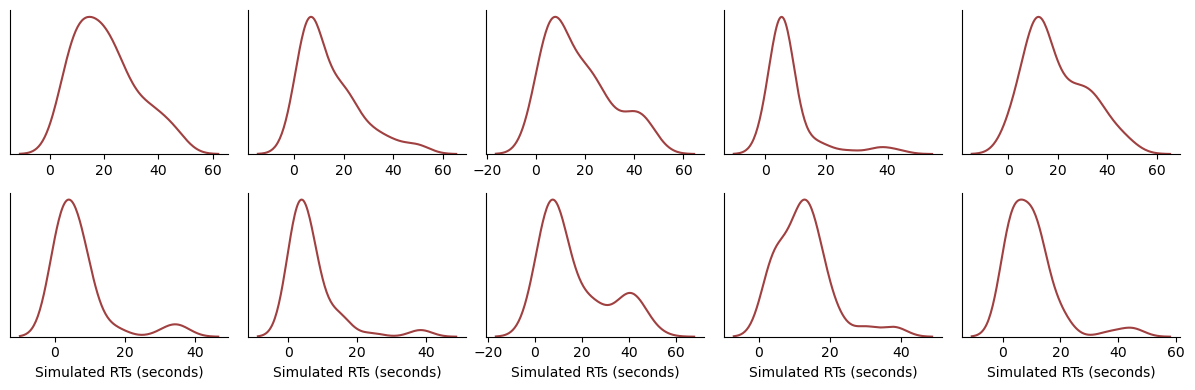

In [23]:
f, axarr = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axarr.flat):
    sns.kdeplot(example_sim["sim_data"][i, :, 0].flatten(), color="maroon", alpha=0.75, ax=ax)
    sns.despine(ax=ax)
    ax.set_ylabel("")
    ax.set_yticks([])
    if i > 4:
        ax.set_xlabel("Simulated RTs (seconds)")
f.tight_layout()

In [24]:
summary_net = bf.networks.SetTransformer(input_dim=2, summary_dim=32, name=f"{model_type}_summary")
#test_inp = model(batch_size=2)
#summary_rep = summary_net(test_inp["sim_data"]).numpy()

#print("Shape of simulated data sets: ", test_inp["sim_data"].shape)
#print("Shape of summary vectors: ", summary_rep.shape)

2024-09-05 17:58:19.971957: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [25]:
inference_net = bf.networks.InvertibleNetwork(
    num_params=len(prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
    name=f"{model_type}_inference",
)

In [26]:
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net, name=f"{model_type}_amortizer")

In [27]:
prior_means, prior_stds = prior.estimate_means_and_stds(n_draws=100000)
prior_means = np.round(prior_means, decimals=1)
prior_stds = np.round(prior_stds, decimals=1)

In [28]:
prior_stds

array([[0.2, 0. , 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
        0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
        0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
        0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
        0.1]])

In [29]:
def configurator(forward_dict):
    """Configure the output of the GenerativeModel for a BayesFlow setup."""

    # Prepare placeholder dict
    out_dict = {}

    # Extract simulated response times
    data = forward_dict["sim_data"]

    # Concatenate rt, resp, context
    out_dict["summary_conditions"] = data

    # Get data generating parameters
    params = forward_dict["prior_draws"]#.astype(np.float32)

    # Standardize parameters
    out_dict["parameters"] = params #np.where(prior_stds, ((params - prior_means) / prior_stds), params)

    return out_dict

In [31]:
trainer = bf.trainers.Trainer(
    generative_model=model, amortizer=amortizer, configurator=configurator, checkpoint_path=f"{model_type}4_model"
)

INFO:root:Initialized empty loss history.
INFO:root:Initialized networks from scratch.
INFO:root:Performing a consistency check with provided components...


ConfigurationError: Could not carry out computations of generative_model ->configurator -> amortizer -> loss! Error trace:
 Exception encountered when calling layer 'sequential_7' (type Sequential).

In this `tf.Variable` creation, the initial value's shape ((39, 128)) is not compatible with the explicitly supplied `shape` argument ((59, 128)).

Call arguments received by layer 'sequential_7' (type Sequential):
  • inputs=tf.Tensor(shape=(2, 59), dtype=float32)
  • training=None
  • mask=None

In [ ]:
amortizer.summary()

In [ ]:
%%time
_ = model(2) # expected time less than a sec

In [ ]:
%%time
sim_data = model(40)

In [ ]:
sim_data["prior_draws"].shape, sim_data["sim_data"].shape

In [ ]:
#history = trainer.train_online(epochs=60, iterations_per_epoch=500, batch_size=100)
history = trainer.train_rounds(rounds=500, sim_per_round=40, epochs=60, batch_size=100, validation_sims=100)
#history = trainer.train_offline(sim_data, epochs=60, batch_size=10)